# Heart Disease Prediction using Machine Learning

## AIMLCZG523 - Machine Learning Operations (MLOps)

### Objective

This project aims to build an end-to-end Machine Learning pipeline to predict the presence of heart disease using clinical patient data from the UCI Machine Learning Repository.

The project demonstrates the complete MLOps lifecycle:

- Data Acquisition
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Model Development
- Experiment Tracking (MLflow)
- API Development (FastAPI)
- Containerization (Docker)
- CI/CD
- Deployment
- Monitoring

---

# 1. Dataset Information

## Dataset

- **Name:** Heart Disease Dataset
- **Source:** UCI Machine Learning Repository
- **Dataset ID:** 45

### Problem Statement

Predict whether a patient has heart disease based on clinical attributes such as age, cholesterol, chest pain type, blood pressure, ECG results, and maximum heart rate.

### Project Dataset

A local copy of the dataset has been stored under:

```text
data/raw/heart.csv
```

All subsequent analysis and model development will use this local copy to ensure reproducibility.

In [10]:
# ===========================
# Import Libraries
# ===========================

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Notebook Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

plt.style.use("default")

In [11]:
# ===========================
# Load Dataset
# ===========================

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "heart.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully from:\n{DATA_PATH}")

Dataset loaded successfully from:
D:\WILP\Semester 3\MLOPs\Heart_Disease_MLOps\data\raw\heart.csv


# 2. Initial Dataset Inspection

## Objective

Before performing exploratory analysis, verify:

- Dataset dimensions
- Feature names
- Data types
- Missing values
- Basic statistics

This step ensures the dataset has been loaded correctly and helps identify potential data quality issues.

In [12]:
# ===========================
# Preview Dataset
# ===========================

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [13]:
# ===========================
# Dataset Information
# ===========================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [14]:
# ===========================
# Missing Values
# ===========================

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

ca          4
thal        2
cp          0
trestbps    0
age         0
           ..
thalach     0
oldpeak     0
exang       0
slope       0
num         0
Length: 14, dtype: int64

In [15]:
# ===========================
# Statistical Summary
# ===========================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
...,...,...,...,...,...,...,...,...
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2
slope,303.0,1.600660,0.616226,1.0,1.0,2.0,2.0,3.0
ca,299.0,0.672241,0.937438,0.0,0.0,0.0,1.0,3.0
thal,301.0,4.734219,1.939706,3.0,3.0,3.0,7.0,7.0


# 3. Initial Observations

### Dataset Summary

| Property | Observation |
|-----------|-------------|
| Number of Samples | 303 |
| Number of Features | 13 |
| Target Variable | `num` |
| Missing Values | Present in `ca` and `thal` |
| Numerical Features | Majority |
| Categorical Features | Several integer-encoded categorical variables |

### Notes

- The original UCI dataset stores the target as `num` with values from 0 to 4.
- For binary classification, this target will later be transformed into:
  - **0** → No heart disease
  - **1** → Presence of heart disease (values 1–4)

This transformation will be performed during the preprocessing stage, not during exploratory data analysis.

# 3. Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset before preprocessing and model development.

The analysis aims to:

- Understand the target variable distribution
- Identify feature distributions
- Detect missing values
- Discover relationships between variables
- Detect outliers
- Identify important predictive features

The insights obtained during EDA will guide preprocessing and feature engineering decisions in subsequent stages.

## 3.1 Target Variable Analysis

### Objective

The target variable is analysed to understand the class distribution.

The original UCI dataset stores the diagnosis as:

- 0 → No heart disease
- 1–4 → Different severity levels of heart disease

For this analysis, we first inspect the original distribution before converting it into a binary target during preprocessing.

In [16]:
# ===========================
# Target Variable Distribution
# ===========================

print("Target Value Counts:\n")
print(df["num"].value_counts().sort_index())

Target Value Counts:

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


C:\Users\arpit\AppData\Local\Temp\ipykernel_1168\105419547.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


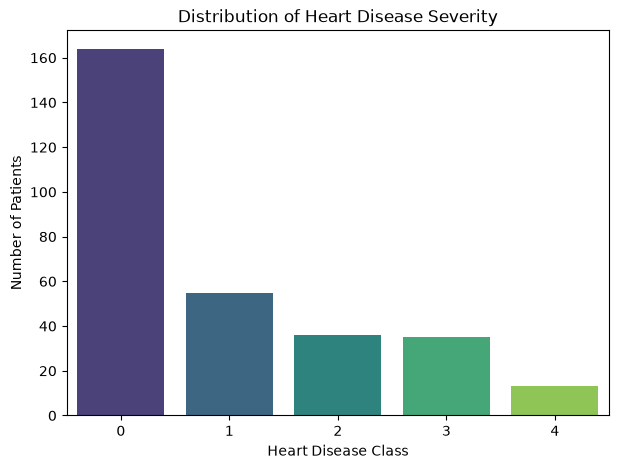

In [17]:
# ===========================
# Target Distribution Plot
# ===========================

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="num",
    palette="viridis"
)

plt.title("Distribution of Heart Disease Severity")
plt.xlabel("Heart Disease Class")
plt.ylabel("Number of Patients")

plt.show()

### Observation

Write your observations after viewing the plot.

Example points to consider:

- Which class has the highest number of patients?
- Is the dataset balanced?
- Would binary classification simplify the problem?

### Observation

The target variable (`num`) represents the severity of heart disease, where:

- 0 indicates the absence of heart disease.
- 1–4 represent increasing severity levels of heart disease.

From the distribution:

- Class 0 contains **164 patients**, making it the largest class.
- The remaining classes (1–4) have significantly fewer observations.
- Class 4 contains only **13 patients**, making it highly underrepresented.

The dataset exhibits **class imbalance** in its original multi-class form, with the majority of patients belonging to the "No Heart Disease" category.

Since the objective of this project is binary classification, the target variable will later be transformed into:

- **0 → No Heart Disease**
- **1 → Presence of Heart Disease (classes 1–4)**

This transformation simplifies the prediction problem and aligns with the assignment requirements.

## 3.2 Feature Distribution Analysis

### Objective

Understand how each numerical feature is distributed across the dataset.

This helps identify:

- skewed distributions
- unusual values
- possible outliers
- feature ranges

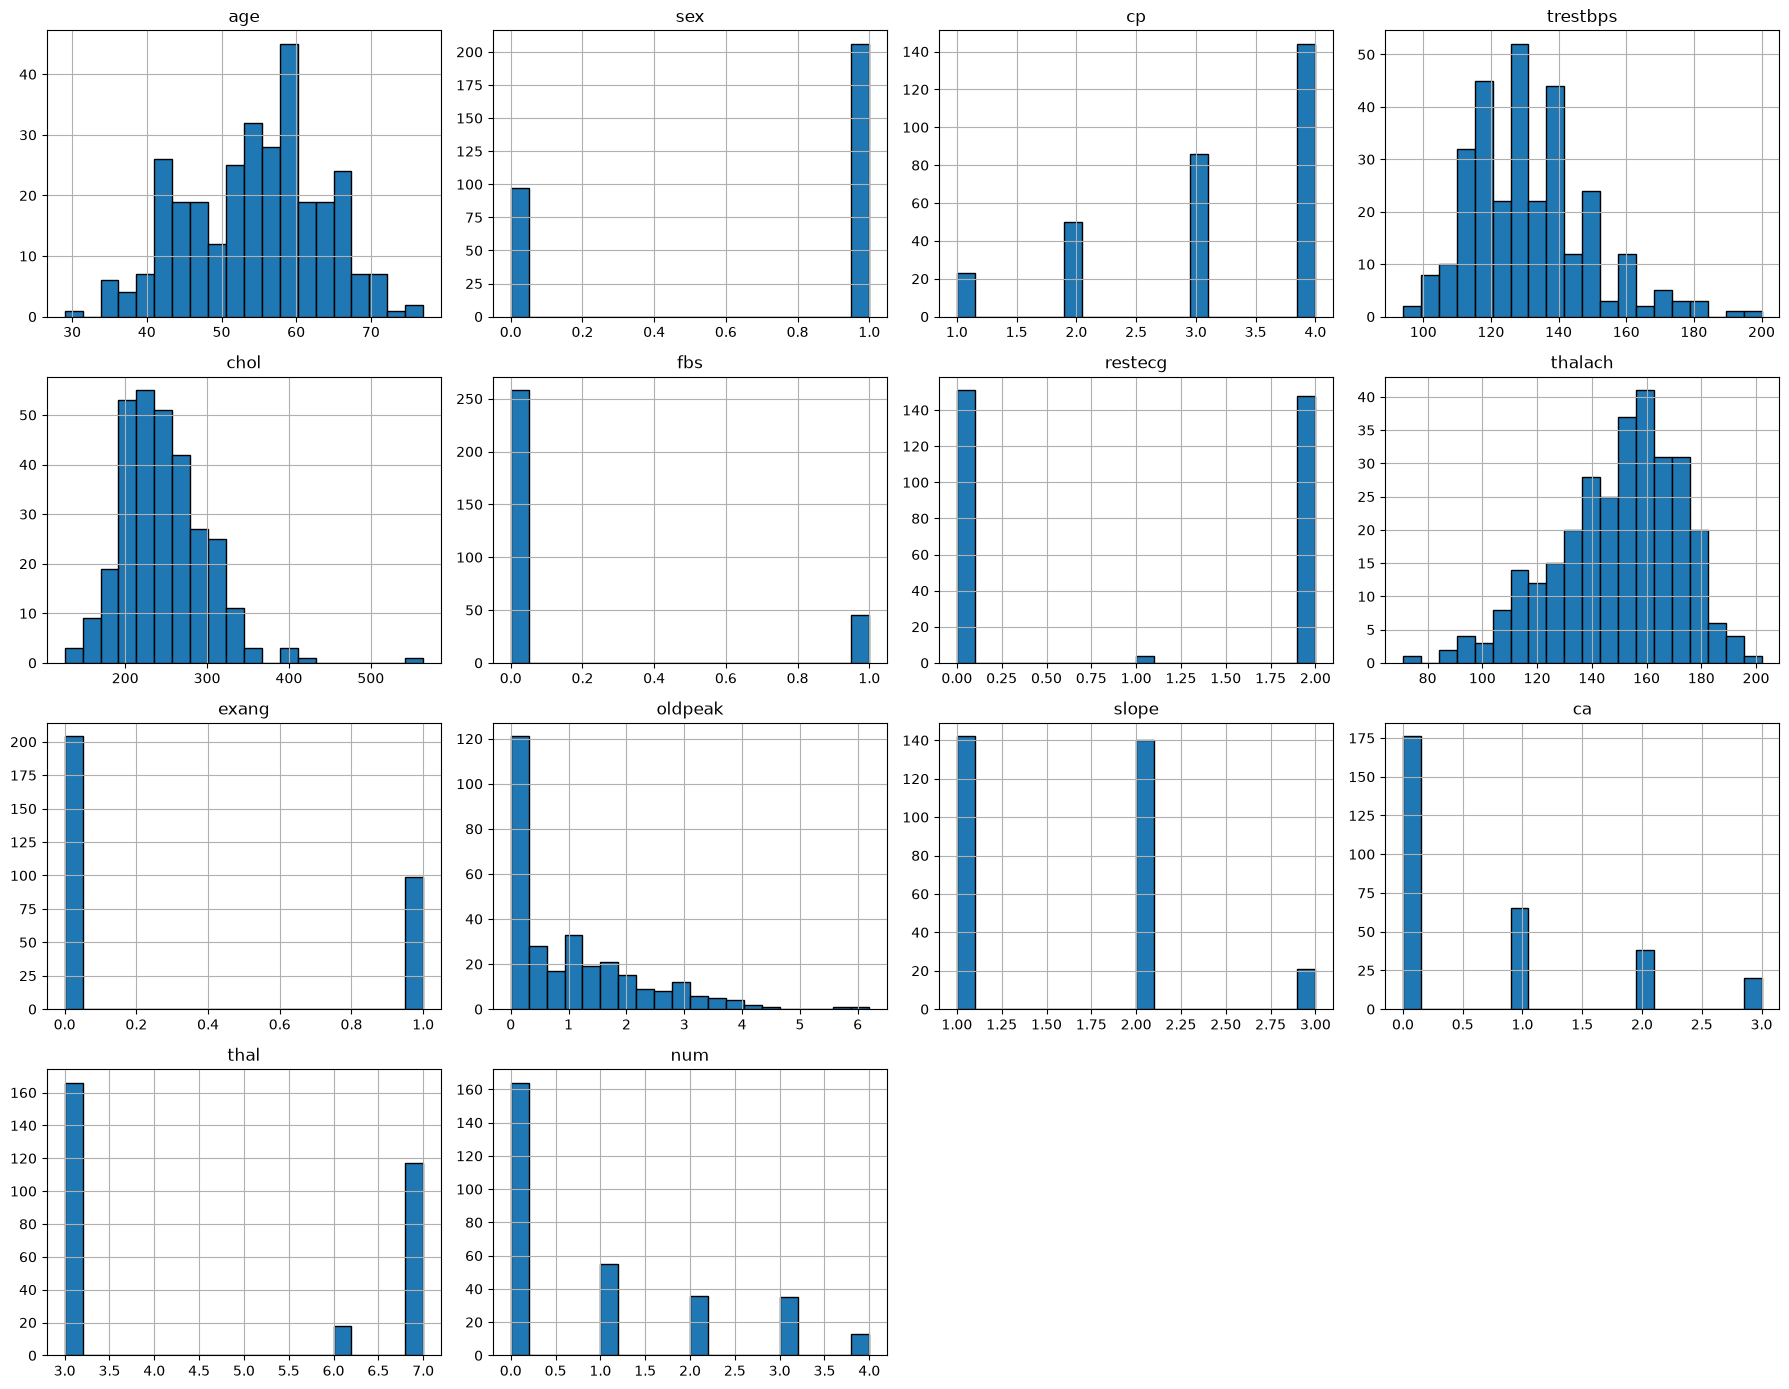

In [18]:
# ===========================
# Histograms
# ===========================

df.hist(
    figsize=(18,14),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()

plt.show()

### Observation

After examining the histograms, note:

- Features that appear normally distributed.
- Features showing skewness.
- Features containing discrete values.
- Features that may contain outliers.

### Observation

The feature distributions reveal several important characteristics of the dataset:

- **Age** follows an approximately bell-shaped distribution, with most patients between **45 and 65 years**.
- **Resting Blood Pressure (`trestbps`)** is centered around **120–140 mmHg**, with a few higher values indicating possible outliers.
- **Cholesterol (`chol`)** shows a right-skewed distribution with a few extremely high values, suggesting the presence of outliers.
- **Maximum Heart Rate (`thalach`)** appears approximately normally distributed.
- **Oldpeak** is positively skewed, with most observations concentrated near lower values.
- Several features such as **sex**, **fbs**, **exang**, **cp**, **restecg**, **slope**, **ca**, and **thal** contain discrete integer values representing categorical variables rather than continuous measurements.

Overall, the dataset contains a mixture of continuous and categorical variables with only a small number of potential outliers in continuous features. These observations will guide the preprocessing and feature engineering steps in later stages of the project.

### Key Insights from Initial EDA

The initial exploratory analysis provides the following insights:

- The dataset contains **303 patient records** with **13 clinical features** and **1 target variable**.
- Missing values are present only in the `ca` and `thal` features.
- The original target variable is multi-class and will require conversion to a binary target for this project.
- Continuous variables generally exhibit reasonable distributions, although a few potential outliers are observed in cholesterol and resting blood pressure.
- Several variables are categorical despite being encoded as numeric values.
- No obvious data integrity issues are observed apart from the small number of missing values.

These findings provide a strong foundation for the preprocessing stage, where missing values, target transformation, and feature preparation will be performed before model training.

## 3.3 Correlation Analysis

### Objective

Correlation analysis is performed to identify linear relationships among numerical variables and determine which features are strongly associated with the target variable.

A correlation heatmap also helps identify multicollinearity between predictor variables.

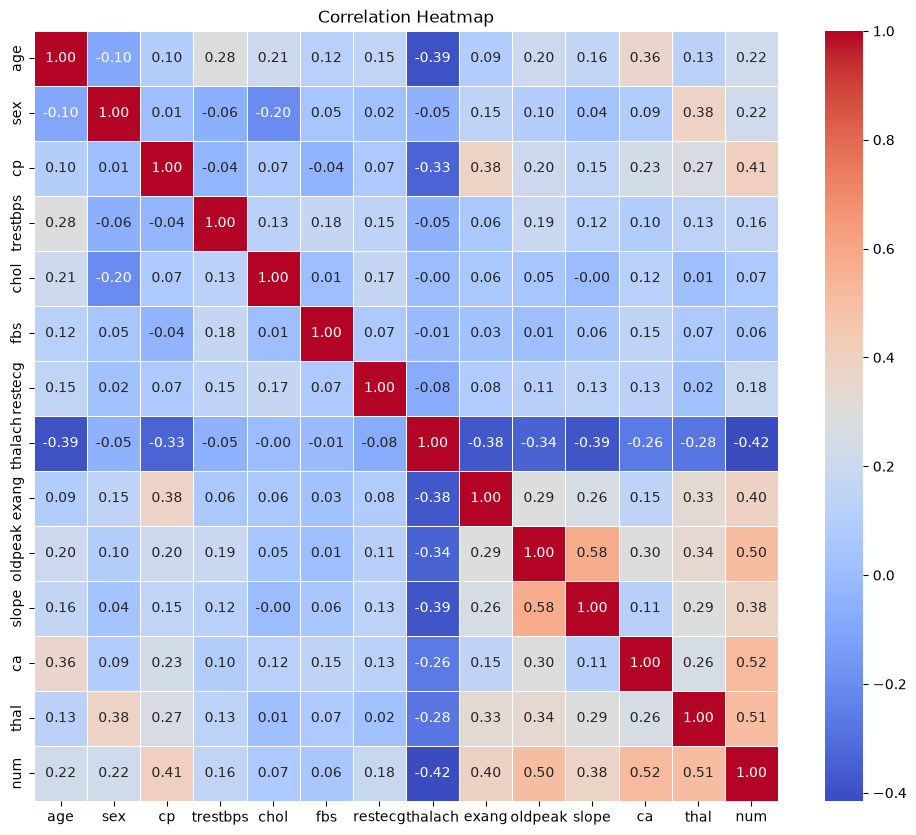

In [19]:
# ===========================
# Correlation Heatmap
# ===========================

plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap indicates varying degrees of linear relationship among the features.

Key observations include:

- Features such as **oldpeak**, **exang**, and **ca** show positive correlation with heart disease severity.
- **thalach** (maximum heart rate achieved) exhibits a negative correlation with the target variable, indicating that lower maximum heart rate is associated with increased disease severity.
- Most feature pairs show low to moderate correlation, suggesting limited multicollinearity.
- No pair of predictor variables demonstrates extremely high correlation, indicating that all features may contribute useful information to the prediction model.

## 3.4 Outlier Analysis

### Objective

Boxplots are used to identify potential outliers within continuous numerical variables.

Outliers may influence model performance and should be considered during preprocessing.

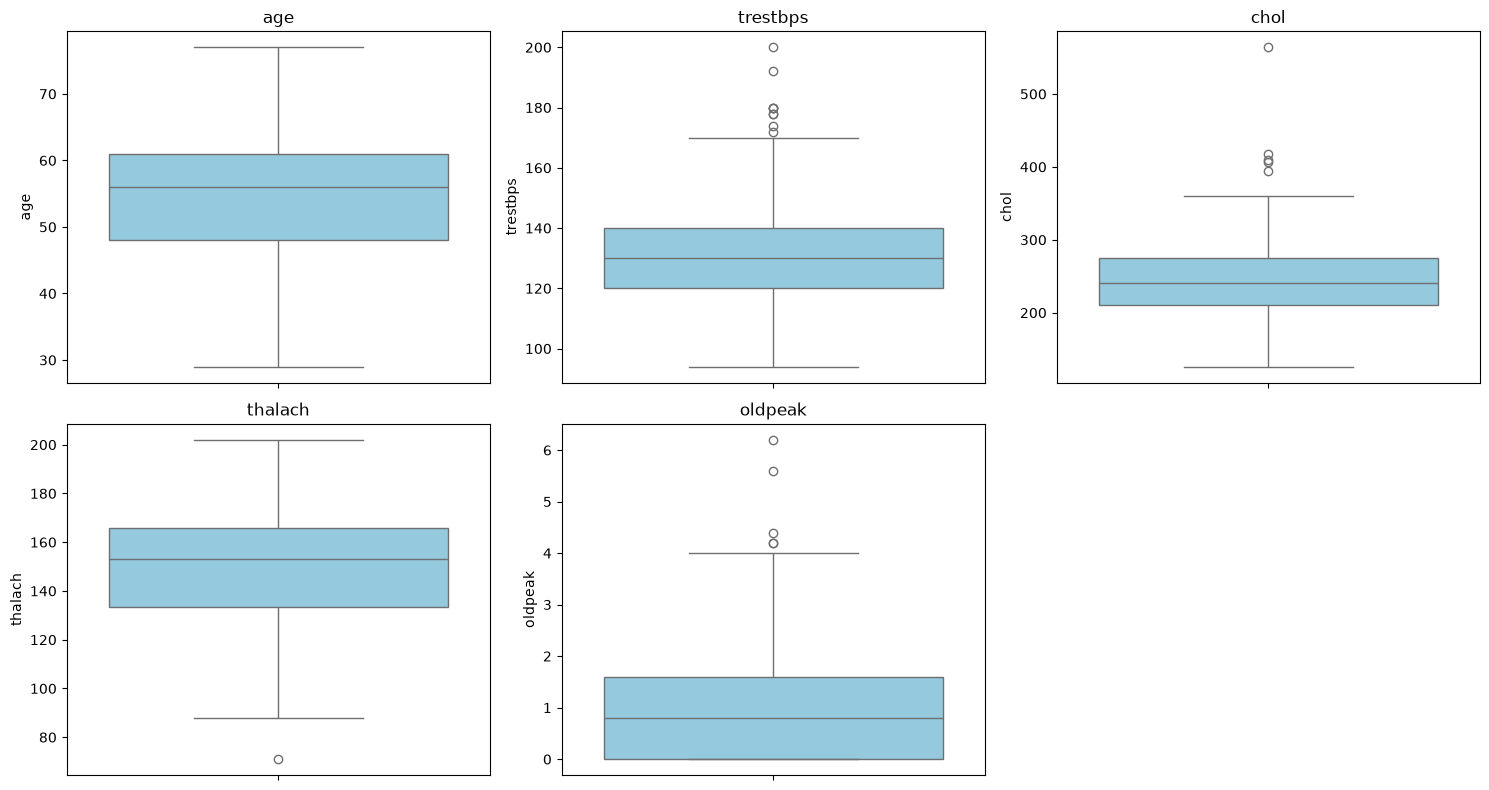

In [20]:
# ===========================
# Boxplots
# ===========================

continuous_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

plt.figure(figsize=(15,8))

for i, col in enumerate(continuous_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()

plt.show()

### Observation

The boxplots reveal several potential outliers.

- Cholesterol contains multiple extreme values.
- Resting blood pressure includes a few unusually high observations.
- Oldpeak contains several high values indicating possible extreme ST depression.
- Age and maximum heart rate show comparatively fewer outliers.

Since tree-based machine learning algorithms are generally robust to outliers, these observations will be considered during preprocessing rather than immediately removing records.

## 3.5 Feature Relationship with Target Variable

### Objective

Visualize how important numerical features differ across heart disease severity classes.

Understanding these relationships helps identify informative predictors for model development.

C:\Users\arpit\AppData\Local\Temp\ipykernel_1168\101875917.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\arpit\AppData\Local\Temp\ipykernel_1168\101875917.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\arpit\AppData\Local\Temp\ipykernel_1168\101875917.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\arpit\AppData\Local\Temp\ipykernel_1168\101875917.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

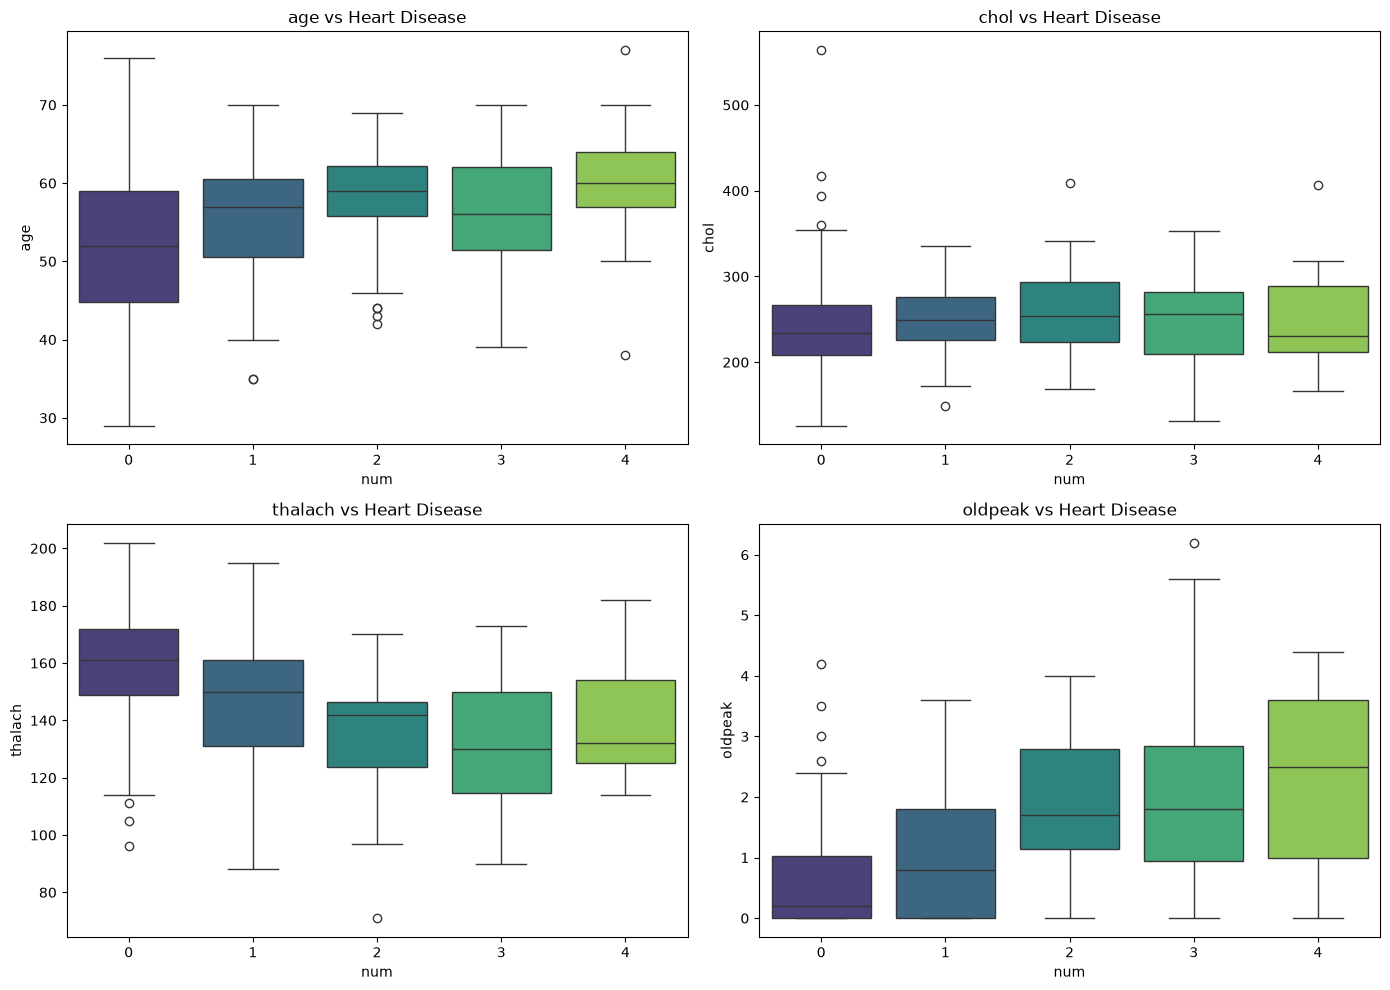

In [21]:
# ===========================
# Feature vs Target
# ===========================

features = [
    "age",
    "chol",
    "thalach",
    "oldpeak"
]

plt.figure(figsize=(14,10))

for i, feature in enumerate(features):
    plt.subplot(2,2,i+1)

    sns.boxplot(
        data=df,
        x="num",
        y=feature,
        palette="viridis"
    )

    plt.title(f"{feature} vs Heart Disease")

plt.tight_layout()

plt.show()

### Observation

The relationship between selected numerical features and heart disease severity indicates meaningful trends.

- Patients with higher heart disease severity generally exhibit larger values of **oldpeak**.
- Maximum heart rate tends to decrease as disease severity increases.
- Cholesterol values overlap considerably across different classes, suggesting weaker predictive power when used independently.
- Age shows moderate variation across disease classes, indicating that age alone is insufficient for prediction but may contribute when combined with other features.

# 3.6 Summary of Exploratory Data Analysis

### Key Findings

The exploratory data analysis revealed the following insights:

- The dataset consists of 303 patient records with 13 clinical features and one target variable.
- Only two variables (`ca` and `thal`) contain missing values.
- The original target variable is multi-class and will later be converted into a binary target for classification.
- Continuous variables generally follow reasonable distributions with a small number of potential outliers.
- The dataset contains a combination of continuous and categorical variables.
- Correlation analysis indicates that features such as `oldpeak`, `ca`, `exang`, and `thalach` are associated with heart disease severity.
- The dataset is suitable for preprocessing and supervised machine learning model development.

The insights obtained during EDA will guide the preprocessing pipeline and model selection in the subsequent stages.